# Strategy 2 — XGBoost Continuous Time-Window
## MP Snapshots at t=0, 6, 12, 18, 24h → ICU Mortality

**Improvement over Strategy 1**: captures the *trajectory* of mechanical power — is it trending up, down, or stable?

**Approach**:
- Five MP snapshots (t=0, 6, 12, 18, 24h) + derived delta features and summary statistics
- XGBoost with Optuna hyperparameter tuning
- 5-fold stratified cross-validation
- SHAP-IQ to show which time-point and interaction matters most
- Doctor-facing summary with temporal pattern visualisation

**Data**: Real MIMIC-IV Clinical Database Demo (v2.2)

In [1]:
import sys, os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.insert(0, PROJECT_ROOT)

from src.utils.helpers import load_config
from src.models.strategy2_window import Strategy2TimeWindow, SNAPSHOT_HOURS
from src.evaluation.metrics import mortality_metrics
from src.deployment.explainer import ExplanationGenerator

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import shapiq

config = load_config(os.path.join(PROJECT_ROOT, 'config', 'config.yaml'))
np.random.seed(config['project']['random_seed'])

print(f"Project: {config['project']['name']}")
print(f"Strategy 2: XGBoost Continuous — MP snapshots at {SNAPSHOT_HOURS}h")

2026-03-27 14:32:39.042 | INFO     | src.utils.helpers:load_config:23 - Configuration loaded from /home/kcdha/Desktop/JD/MP/mechanical_power/config/config.yaml


Project: mechanical_power
Strategy 2: XGBoost Continuous — MP snapshots at [0, 6, 12, 18, 24]h


## 1. Load Processed Cohort

In [2]:
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'processed', 'processed_cohort.parquet')
df = pd.read_parquet(DATA_PATH)
print(f"Loaded: {df.shape[0]:,} hourly rows × {df.shape[1]} columns")
print(f"Unique stays: {df['stay_id'].nunique()}")

Loaded: 13,627,844 hourly rows × 39 columns
Unique stays: 47397


## 2. Build Time-Window Feature Matrix

For each patient we extract MP (and SpO2 / driving pressure) at five snapshot hours, plus derived delta and summary statistics. This gives the model a sense of *trajectory*, not just a single snapshot.

In [3]:
SNAPSHOT_HOURS_USE = [0, 6, 12, 18, 24]  # matches Strategy2TimeWindow

AVAIL_STATIC = ['age', 'predicted_body_weight', 'weight_kg', 'height_cm']
AVAIL_VITALS = ['heart_rate', 'mean_arterial_pressure', 'spo2', 'temperature', 'gcs']
AVAIL_LABS   = ['ph', 'pao2', 'paco2', 'pf_ratio', 'lactate', 'creatinine', 'bilirubin', 'platelet_count']
AVAIL_VENT   = ['tidal_volume', 'respiratory_rate', 'peep', 'fio2',
                'plateau_pressure', 'driving_pressure', 'compliance',
                'minute_ventilation', 'tidal_volume_per_kg']

def avail(cols): return [c for c in cols if c in df.columns]

STATIC_COLS = avail(AVAIL_STATIC)
BASE_COLS   = avail(AVAIL_STATIC + AVAIL_VITALS + AVAIL_LABS + AVAIL_VENT)

def build_time_window_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    For each stay, extract:
    - Baseline static features at t=0
    - MP at 5 snapshot hours (0, 6, 12, 18, 24)
    - MP deltas between consecutive snapshots
    - MP summary stats (mean, std, trend)
    - SpO2 at 5 snapshot hours
    - Driving pressure at 5 snapshots
    """
    records = []
    for stay_id, grp in df.groupby('stay_id'):
        grp = grp.sort_values('hour_index').reset_index(drop=True)
        row0 = grp.iloc[0]
        
        feat = {col: row0.get(col, np.nan) for col in BASE_COLS}
        feat['stay_id'] = stay_id
        feat['label']   = int(row0.get('hospital_expire_flag', 0))
        
        # Snapshot values
        for h in SNAPSHOT_HOURS_USE:
            # Find row closest to target hour
            sub = grp[grp['hour_index'] <= h]
            if sub.empty:
                sub = grp.iloc[:1]
            row_h = sub.iloc[-1]  # last row up to hour h
            
            feat[f'mp_{h}h']  = row_h.get('mechanical_power', np.nan)
            feat[f'spo2_{h}h'] = row_h.get('spo2', np.nan)
            feat[f'dp_{h}h']   = row_h.get('driving_pressure', np.nan)
            feat[f'map_{h}h']  = row_h.get('mean_arterial_pressure', np.nan)
        
        # MP deltas between consecutive snapshots
        mp_snaps = [feat[f'mp_{h}h'] for h in SNAPSHOT_HOURS_USE]
        for i in range(len(SNAPSHOT_HOURS_USE) - 1):
            h0 = SNAPSHOT_HOURS_USE[i]
            h1 = SNAPSHOT_HOURS_USE[i + 1]
            v0, v1 = mp_snaps[i], mp_snaps[i + 1]
            feat[f'mp_delta_{h0}to{h1}'] = (v1 - v0) if (pd.notna(v0) and pd.notna(v1)) else np.nan
        
        # MP summary over first 24h
        h24 = grp[grp['hour_index'] <= 24]
        mp_s = h24['mechanical_power'].dropna()
        feat['mp_mean_24h'] = mp_s.mean()  if len(mp_s) > 0 else np.nan
        feat['mp_std_24h']  = mp_s.std()   if len(mp_s) > 1 else 0.0
        feat['mp_max_24h']  = mp_s.max()   if len(mp_s) > 0 else np.nan
        feat['mp_trend']    = (mp_snaps[-1] - mp_snaps[0]) if (pd.notna(mp_snaps[-1]) and pd.notna(mp_snaps[0])) else np.nan
        feat['mp_above20_frac'] = float((mp_s > 20).mean()) if len(mp_s) > 0 else np.nan
        feat['mp_above17_frac'] = float((mp_s > 17).mean()) if len(mp_s) > 0 else np.nan
        
        # SpO2 summary
        spo2_s = h24['spo2'].dropna()
        feat['spo2_min_24h']  = spo2_s.min()  if len(spo2_s) > 0 else np.nan
        feat['spo2_mean_24h'] = spo2_s.mean() if len(spo2_s) > 0 else np.nan
        
        # n_hours with data
        feat['n_mp_obs'] = int(mp_s.notna().sum() if hasattr(mp_s, 'notna') else len(mp_s))
        
        records.append(feat)
    
    return pd.DataFrame(records)

patient_df = build_time_window_features(df)
FEAT_COLS  = [c for c in patient_df.columns if c not in ('stay_id','label')]

print(f"Patient-level dataset: {patient_df.shape}")
print(f"  Mortality: {patient_df['label'].mean():.1%}")
print(f"  MP snapshots available per patient:")
for h in SNAPSHOT_HOURS_USE:
    n = patient_df[f'mp_{h}h'].notna().sum()
    print(f"    t={h}h: {n}/{len(patient_df)} patients ({n/len(patient_df):.0%})")

Patient-level dataset: (47397, 61)
  Mortality: 18.7%
  MP snapshots available per patient:
    t=0h: 4534/47397 patients (10%)
    t=6h: 3013/47397 patients (6%)
    t=12h: 2201/47397 patients (5%)
    t=18h: 1912/47397 patients (4%)
    t=24h: 1822/47397 patients (4%)


In [4]:
# Build X, y — median impute remaining NaN
X_raw = patient_df[FEAT_COLS].copy()
y = patient_df['label'].values

for col in X_raw.columns:
    med = X_raw[col].median()
    X_raw[col] = X_raw[col].fillna(med if pd.notna(med) else 0)

X = X_raw.values.astype(np.float32)

print(f"Feature matrix X: {X.shape}")
print(f"Labels y: {y.shape}  (positive={y.mean():.1%})")

Feature matrix X: (47397, 59)
Labels y: (47397,)  (positive=18.7%)


## 3. Optuna Hyperparameter Tuning + Nested 5-Fold CV

In [5]:
def objective(trial, X_tr, y_tr, X_va, y_va):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 50, 600),
        'max_depth':        trial.suggest_int('max_depth', 2, 8),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 5.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.1, 5.0),
        'eval_metric': 'logloss',        'random_state': 42, 'n_jobs': -1,
        'scale_pos_weight': (y_tr==0).sum() / max((y_tr==1).sum(), 1),
    }
    model = xgb.XGBClassifier(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
    return roc_auc_score(y_va, model.predict_proba(X_va)[:, 1])

N_FOLDS  = 5
N_TRIALS = 40

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
cv_results = []
best_params_list = []

print(f"Running {N_FOLDS}-fold CV with {N_TRIALS} Optuna trials/fold ...")
for fold_i, (tr_idx, te_idx) in enumerate(skf.split(X, y)):
    X_tr_full, X_te = X[tr_idx], X[te_idx]
    y_tr_full, y_te = y[tr_idx], y[te_idx]
    X_tr, X_va, y_tr, y_va = train_test_split(
        X_tr_full, y_tr_full, test_size=0.2, stratify=y_tr_full, random_state=fold_i)
    
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=42+fold_i))
    study.optimize(lambda t: objective(t, X_tr, y_tr, X_va, y_va),
                   n_trials=N_TRIALS, show_progress_bar=False)
    
    best_p = study.best_params
    best_p.update({'eval_metric': 'logloss',        'random_state': 42, 'n_jobs': -1,
                   'scale_pos_weight': (y_tr_full==0).sum()/max((y_tr_full==1).sum(),1)})
    best_params_list.append(best_p)

    # Strip early_stopping_rounds — final fit has no eval_set
    final_p = {k: v for k, v in best_p.items() if k != "early_stopping_rounds"}
    
    final_model = xgb.XGBClassifier(**final_p)
    final_model.fit(X_tr_full, y_tr_full, verbose=False)
    
    proba = final_model.predict_proba(X_te)[:, 1]
    auroc = roc_auc_score(y_te, proba)
    auprc = average_precision_score(y_te, proba)
    cv_results.append({'fold': fold_i+1, 'auroc': auroc, 'auprc': auprc,
                       'best_val_auroc': study.best_value})
    print(f"  Fold {fold_i+1}: AUROC={auroc:.4f}  AUPRC={auprc:.4f}  (val={study.best_value:.4f})")

cv_df = pd.DataFrame(cv_results)
print(f"\nCV AUROC: {cv_df['auroc'].mean():.4f} ± {cv_df['auroc'].std():.4f}")
print(f"CV AUPRC: {cv_df['auprc'].mean():.4f} ± {cv_df['auprc'].std():.4f}")

Running 5-fold CV with 40 Optuna trials/fold ...
  Fold 1: AUROC=0.7906  AUPRC=0.5259  (val=0.7962)
  Fold 2: AUROC=0.7940  AUPRC=0.5274  (val=0.7928)
  Fold 3: AUROC=0.7857  AUPRC=0.5146  (val=0.7868)
  Fold 4: AUROC=0.7904  AUPRC=0.5114  (val=0.7991)
  Fold 5: AUROC=0.7875  AUPRC=0.5188  (val=0.7890)

CV AUROC: 0.7896 ± 0.0032
CV AUPRC: 0.5196 ± 0.0069


## 4. Final Model

In [6]:
best_fold_idx = cv_df['best_val_auroc'].idxmax()
best_params_final = best_params_list[best_fold_idx]
best_params_final['n_estimators'] = min(best_params_final.get('n_estimators', 300) + 50, 700)

print("Best hyperparameters:")
for k, v in sorted(best_params_final.items()):
    if k not in ('eval_metric', 'use_label_encoder'):
        print(f"  {k}: {v}")

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
final_xgb = xgb.XGBClassifier(**best_params_final)
final_xgb.fit(X_tr, y_tr, verbose=False)

y_prob = final_xgb.predict_proba(X_te)[:, 1]
final_metrics = mortality_metrics(y_te, y_prob)

print(f"\nFinal Test Metrics:")
for k, v in final_metrics.items():
    print(f"  {k}: {v:.4f}")

os.makedirs(os.path.join(PROJECT_ROOT, 'notebooks', 'models'), exist_ok=True)
final_xgb.save_model(os.path.join(PROJECT_ROOT, 'notebooks', 'models', 'strategy2_xgb.json'))
print("Model saved to notebooks/models/strategy2_xgb.json")

Best hyperparameters:
  colsample_bytree: 0.9481740533351146
  gamma: 0.5327843397817303
  learning_rate: 0.021649447451458154
  max_depth: 7
  min_child_weight: 7
  n_estimators: 616
  n_jobs: -1
  random_state: 42
  reg_alpha: 2.997745044368219
  reg_lambda: 3.8956693150055175
  scale_pos_weight: 4.341315678264544
  subsample: 0.7818311147176069

Final Test Metrics:
  auroc: 0.7930
  auprc: 0.5207
  sensitivity: 0.6501
  specificity: 0.7603
  ppv: 0.3845
  npv: 0.9042
Model saved to notebooks/models/strategy2_xgb.json


## 5. Performance Plots

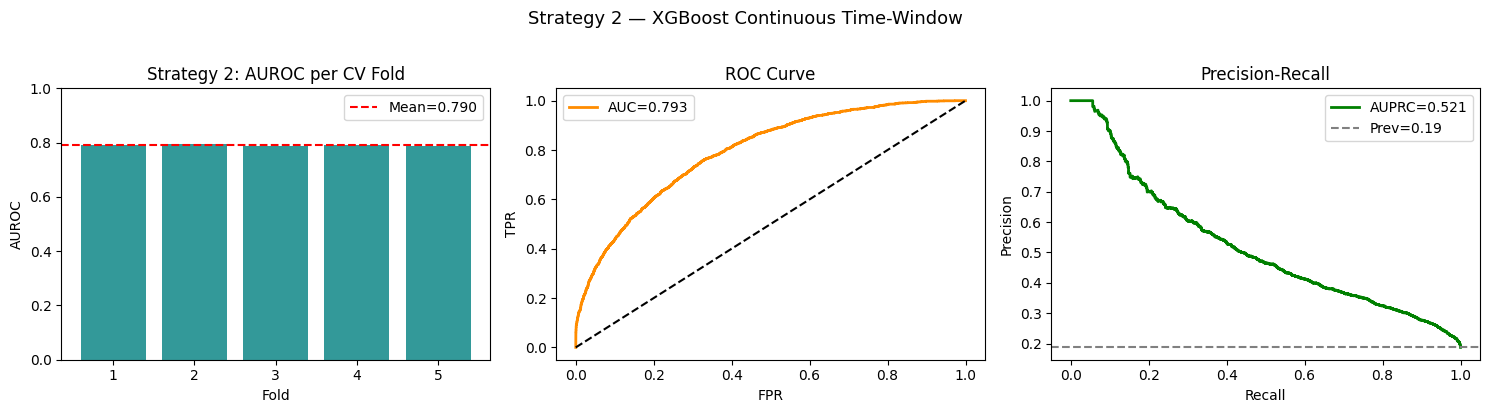

In [7]:
os.makedirs(os.path.join(PROJECT_ROOT, 'notebooks', 'figures'), exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# AUROC per fold
ax = axes[0]
ax.bar(cv_df['fold'], cv_df['auroc'], color='teal', alpha=0.8)
ax.axhline(cv_df['auroc'].mean(), color='red', ls='--', label=f"Mean={cv_df['auroc'].mean():.3f}")
ax.set_xlabel('Fold'); ax.set_ylabel('AUROC')
ax.set_title('Strategy 2: AUROC per CV Fold'); ax.legend(); ax.set_ylim(0, 1)

# ROC curve
fpr, tpr, _ = roc_curve(y_te, y_prob)
ax = axes[1]
ax.plot(fpr, tpr, lw=2, color='darkorange', label=f'AUC={roc_auc_score(y_te,y_prob):.3f}')
ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.set_title('ROC Curve'); ax.legend()

# PR curve
prec, rec, _ = precision_recall_curve(y_te, y_prob)
ax = axes[2]
ax.plot(rec, prec, lw=2, color='green',
        label=f'AUPRC={average_precision_score(y_te,y_prob):.3f}')
ax.axhline(y_te.mean(), ls='--', color='gray', label=f'Prev={y_te.mean():.2f}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.set_title('Precision-Recall'); ax.legend()

plt.suptitle('Strategy 2 — XGBoost Continuous Time-Window', fontsize=13, y=1.02)
plt.tight_layout()
fig_path = os.path.join(PROJECT_ROOT, 'notebooks', 'figures', 'strategy2_performance.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

## 6. MP Trajectory Visualisation by Outcome

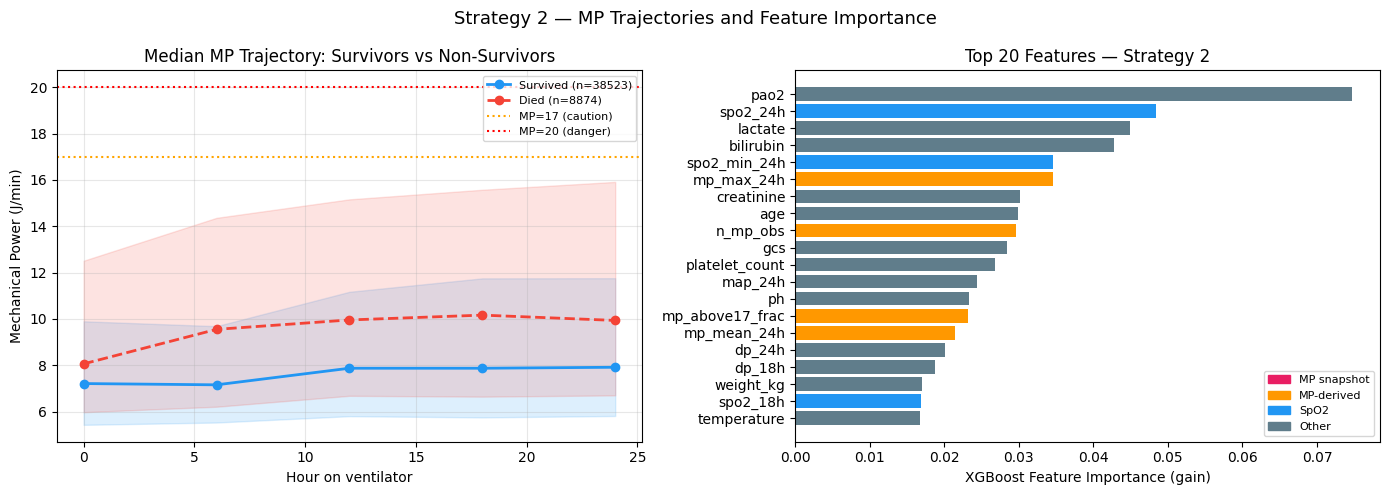

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Mean MP trajectory: survivors vs non-survivors
for label, name, color, ls in [(0,'Survived','#2196F3','-'), (1,'Died','#F44336','--')]:
    sub = patient_df[patient_df['label'] == label]
    mp_means = [sub[f'mp_{h}h'].median() for h in SNAPSHOT_HOURS_USE]
    mp_q25   = [sub[f'mp_{h}h'].quantile(0.25) for h in SNAPSHOT_HOURS_USE]
    mp_q75   = [sub[f'mp_{h}h'].quantile(0.75) for h in SNAPSHOT_HOURS_USE]
    
    ax = axes[0]
    ax.plot(SNAPSHOT_HOURS_USE, mp_means, marker='o', lw=2, ls=ls, color=color,
            label=f'{name} (n={len(sub)})')
    ax.fill_between(SNAPSHOT_HOURS_USE, mp_q25, mp_q75, alpha=0.15, color=color)

axes[0].axhline(17, color='orange', ls=':', lw=1.5, label='MP=17 (caution)')
axes[0].axhline(20, color='red',    ls=':', lw=1.5, label='MP=20 (danger)')
axes[0].set_xlabel('Hour on ventilator')
axes[0].set_ylabel('Mechanical Power (J/min)')
axes[0].set_title('Median MP Trajectory: Survivors vs Non-Survivors')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Feature importance for snapshot-specific features
importance_df = pd.DataFrame({
    'feature': FEAT_COLS,
    'importance': final_xgb.feature_importances_
}).sort_values('importance', ascending=False).head(20)

color_map = []
for fn in importance_df['feature']:
    if any(f'mp_{h}h' == fn for h in SNAPSHOT_HOURS_USE):
        color_map.append('#E91E63')  # MP snapshots in pink
    elif 'mp_' in fn:
        color_map.append('#FF9800')  # MP-derived in orange
    elif 'spo2' in fn:
        color_map.append('#2196F3')  # SpO2 in blue
    else:
        color_map.append('#607D8B')  # other in grey

axes[1].barh(importance_df['feature'][::-1], importance_df['importance'][::-1],
             color=color_map[::-1])
axes[1].set_xlabel('XGBoost Feature Importance (gain)')
axes[1].set_title('Top 20 Features — Strategy 2')

# Legend patches
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color='#E91E63', label='MP snapshot'),
    mpatches.Patch(color='#FF9800', label='MP-derived'),
    mpatches.Patch(color='#2196F3', label='SpO2'),
    mpatches.Patch(color='#607D8B', label='Other'),
]
axes[1].legend(handles=legend_handles, fontsize=8, loc='lower right')

plt.suptitle('Strategy 2 — MP Trajectories and Feature Importance', fontsize=13)
plt.tight_layout()
fig_path = os.path.join(PROJECT_ROOT, 'notebooks', 'figures', 'strategy2_trajectories.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

## 7. SHAP-IQ: Shapley Interaction Indices for Time-Window Features

In [9]:
print("Computing SHAP-IQ interactions for Strategy 2 ...")

np.random.seed(42)
bg_idx = np.random.choice(len(X_tr), size=min(50, len(X_tr)), replace=False)

def model_fn(x):
    return final_xgb.predict_proba(x.astype(np.float32))[:, 1]

explainer = shapiq.TabularExplainer(
    model=model_fn,
    data=X_tr[bg_idx],
    index='SII',
    max_order=2,
    sample_size=64,
)

test_ivals = explainer.explain_X(X_te, budget=128)

# Main effects
all_main = np.array([iv.get_n_order_values(1) for iv in test_ivals])
mean_main = np.abs(all_main).mean(axis=0)
feature_importance = pd.Series(mean_main, index=FEAT_COLS).sort_values(ascending=False)

print("Top-15 features (SHAP-IQ main effects):")
print(feature_importance.head(15).to_string())

Computing SHAP-IQ interactions for Strategy 2 ...
Top-15 features (SHAP-IQ main effects):
age               0.068411
weight_kg         0.034427
pao2              0.027086
mp_max_24h        0.026847
platelet_count    0.025754
creatinine        0.021516
spo2_mean_24h     0.019188
heart_rate        0.018921
lactate           0.016046
spo2_min_24h      0.014923
n_mp_obs          0.014140
bilirubin         0.013649
spo2_24h          0.012642
map_18h           0.012312
map_24h           0.011732


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Main effects
ax = axes[0]
top15 = feature_importance.head(15)
colors = ['#E91E63' if 'mp_' in n and 'h' in n else
          '#FF9800' if 'mp' in n else
          '#2196F3' if 'spo2' in n else
          '#607D8B' for n in top15.index]
ax.barh(top15.index[::-1], top15.values[::-1], color=colors[::-1])
ax.set_xlabel('Mean |Shapley Interaction Index|')
ax.set_title('SHAP-IQ Main Effects\n(Strategy 2 — Time-Window)')

# Interaction matrix — focus on MP snapshots and top features
focus_feats = [f'mp_{h}h' for h in SNAPSHOT_HOURS_USE if f'mp_{h}h' in FEAT_COLS]
focus_feats += [c for c in ['spo2', 'driving_pressure', 'age', 'pf_ratio']
                if c in feature_importance.head(15).index and c not in focus_feats]
focus_feats = focus_feats[:10]  # max 10
feat_indices = [FEAT_COLS.index(f) for f in focus_feats if f in FEAT_COLS]

if len(feat_indices) >= 2:
    n = len(feat_indices)
    int_mat = np.zeros((n, n))
    for iv in test_ivals:
        pairs = iv.get_n_order_values(2)
        for (i, j), v in pairs.items():
            if i in feat_indices and j in feat_indices:
                ii = feat_indices.index(i)
                jj = feat_indices.index(j)
                int_mat[ii, jj] += abs(v)
                int_mat[jj, ii] += abs(v)
    int_mat /= max(len(test_ivals), 1)
    
    ax = axes[1]
    sns.heatmap(int_mat,
                xticklabels=[FEAT_COLS[i] for i in feat_indices],
                yticklabels=[FEAT_COLS[i] for i in feat_indices],
                cmap='YlOrRd', ax=ax, square=True,
                cbar_kws={'label': 'Mean |SII|'})
    ax.set_title('SHAP-IQ: MP Snapshot × Feature Interactions')
    plt.xticks(rotation=45, ha='right')

plt.suptitle('Strategy 2 — SHAP-IQ Explainability', fontsize=13, y=1.02)
plt.tight_layout()
fig_path = os.path.join(PROJECT_ROOT, 'notebooks', 'figures', 'strategy2_shapiq.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

## 8. Doctor-Facing Output with Temporal Pattern

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
knn = NearestNeighbors(n_neighbors=min(11, len(X)-1), metric='euclidean')
knn.fit(X_scaled)

def doctor_report_s2(patient_idx: int):
    row = patient_df.iloc[patient_idx]
    x_q = X_scaled[patient_idx:patient_idx+1]
    dists, idxs = knn.kneighbors(x_q)
    sim_idxs = idxs[0][1:]
    sim_y    = y[sim_idxs]
    
    prob     = final_xgb.predict_proba(X[patient_idx:patient_idx+1].astype(np.float32))[0, 1]
    surv_prob = 1 - prob
    
    mp_snaps = [row.get(f'mp_{h}h', np.nan) for h in SNAPSHOT_HOURS_USE]
    trend_desc = ''
    if pd.notna(mp_snaps[0]) and pd.notna(mp_snaps[-1]):
        diff = mp_snaps[-1] - mp_snaps[0]
        if diff > 1:
            trend_desc = f'RISING (+{diff:.1f} J/min over 24h) ⚠'
        elif diff < -1:
            trend_desc = f'FALLING ({diff:.1f} J/min over 24h) ✓'
        else:
            trend_desc = f'STABLE (Δ={diff:.1f} J/min)'
    
    sim_surv_rate = (sim_y == 0).mean()
    n_sim = len(sim_idxs)
    
    # Optimal MP from survivors in similar cohort
    surv_sim = sim_idxs[sim_y == 0]
    if len(surv_sim) > 0:
        mp0_idx = FEAT_COLS.index('mp_0h') if 'mp_0h' in FEAT_COLS else None
        if mp0_idx is not None:
            opt_mp = np.nanmedian(X[surv_sim, mp0_idx])
        else:
            opt_mp = None
    else:
        opt_mp = None
    
    print("=" * 65)
    print("  CLINICAL DECISION SUPPORT — MP TREND ANALYSIS")
    print("=" * 65)
    print(f"  Patient: Stay #{row.get('stay_id','?')}")
    print(f"  Age: {row.get('age',np.nan):.0f} years" if pd.notna(row.get('age',np.nan)) else "  Age: N/A")
    print()
    print("  MP Trajectory:")
    for h, mp_val in zip(SNAPSHOT_HOURS_USE, mp_snaps):
        bar = '█' * int(mp_val/2) if pd.notna(mp_val) else ''
        val_str = f"{mp_val:.1f} J/min {bar}" if pd.notna(mp_val) else 'N/A'
        print(f"    t={h:>2}h: {val_str}")
    if trend_desc:
        print(f"  Trend: {trend_desc}")
    print()
    print(f"  Similar patients: {n_sim}")
    print(f"  Survival rate in similar cohort: {sim_surv_rate:.0%}")
    if opt_mp is not None:
        cur_mp = row.get('mp_0h', np.nan)
        if pd.notna(cur_mp) and pd.notna(opt_mp):
            diff = opt_mp - cur_mp
            dir_str = 'decrease' if diff < 0 else 'increase'
            print(f"  Optimal MP target (from {len(surv_sim)} similar survivors): {opt_mp:.1f} J/min")
            print(f"  Recommended: {dir_str} by {abs(diff):.1f} J/min")
    print()
    print(f"  Predicted survival probability: {surv_prob:.0%}")
    risk_level = 'HIGH' if prob > 0.5 else 'MODERATE' if prob > 0.3 else 'LOW'
    print(f"  Risk level: {risk_level}")
    
    mp_above17 = row.get('mp_above17_frac', np.nan)
    if pd.notna(mp_above17) and mp_above17 > 0.5:
        print(f"  ⚠  MP above 17 J/min for {mp_above17:.0%} of first 24h — consider reducing")
    print("=" * 65)

# Show 3 example patients
print("\n  === DOCTOR REPORTS — STRATEGY 2 TEMPORAL ANALYSIS ===\n")
for idx in list(np.where(y == 1)[0])[:1] + list(np.where(y == 0)[0])[:2]:
    try:
        doctor_report_s2(idx)
        print()
    except Exception as e:
        print(f"  (Skipped: {e})")

## 9. MP Snapshot Summary Statistics

In [ ]:
fig, axes = plt.subplots(1, len(SNAPSHOT_HOURS_USE), figsize=(16, 4), sharey=False)

for i, h in enumerate(SNAPSHOT_HOURS_USE):
    col = f'mp_{h}h'
    for label, name, color in [(0,'Survived','#2196F3'), (1,'Died','#F44336')]:
        subset = patient_df[patient_df['label']==label][col].dropna()
        if len(subset) > 0:
            axes[i].hist(subset, bins=10, alpha=0.6, color=color,
                        label=f'{name} (n={len(subset)})')
    axes[i].set_title(f't = {h}h')
    axes[i].set_xlabel('MP (J/min)')
    if i == 0: axes[i].set_ylabel('Count')
    axes[i].axvline(17, color='orange', ls=':', lw=1)
    axes[i].axvline(20, color='red',    ls=':', lw=1)
    if i == 0: axes[i].legend(fontsize=7)

plt.suptitle('Strategy 2 — MP Distribution at Each Snapshot: Survivors vs Non-Survivors', fontsize=12)
plt.tight_layout()
fig_path = os.path.join(PROJECT_ROOT, 'notebooks', 'figures', 'strategy2_mp_snapshots.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print("\nStrategy 2 complete.")
print(f"CV AUROC: {cv_df['auroc'].mean():.4f} ± {cv_df['auroc'].std():.4f}")
print(f"Test AUROC: {final_metrics['auroc']:.4f}  |  AUPRC: {final_metrics['auprc']:.4f}")